<a href="https://colab.research.google.com/github/poovitha123456/192312183-ITA0604_-Machine-Learning/blob/main/IET%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WATER QUALITY DATASET
         pH Turbidity     TDS  Chlorine Microbial     Source           Target
0   Neutral       Low  Normal  Adequate    Absent   Borewell     Safe for Use
1   Neutral       Low  Normal  Adequate    Absent        Tap     Safe for Use
2   Neutral       Low  Normal  Adequate    Absent  Rainwater     Safe for Use
3   Neutral       Low  Normal  Adequate    Absent      Canal     Safe for Use
4   Neutral       Low  Normal  Adequate   Present        Tap  Needs Treatment
5   Neutral       Low    High  Adequate    Absent        Tap  Needs Treatment
6   Neutral      High  Normal  Adequate    Absent        Tap  Needs Treatment
7    Acidic       Low  Normal  Adequate    Absent        Tap  Needs Treatment
8   Neutral       Low  Normal       Low    Absent        Tap  Needs Treatment
9  Alkaline      High    High       Low   Present      Canal  Needs Treatment

FIRST FIVE RECORDS
        pH Turbidity     TDS  Chlorine Microbial     Source           Target
0  Neutral       Low  N

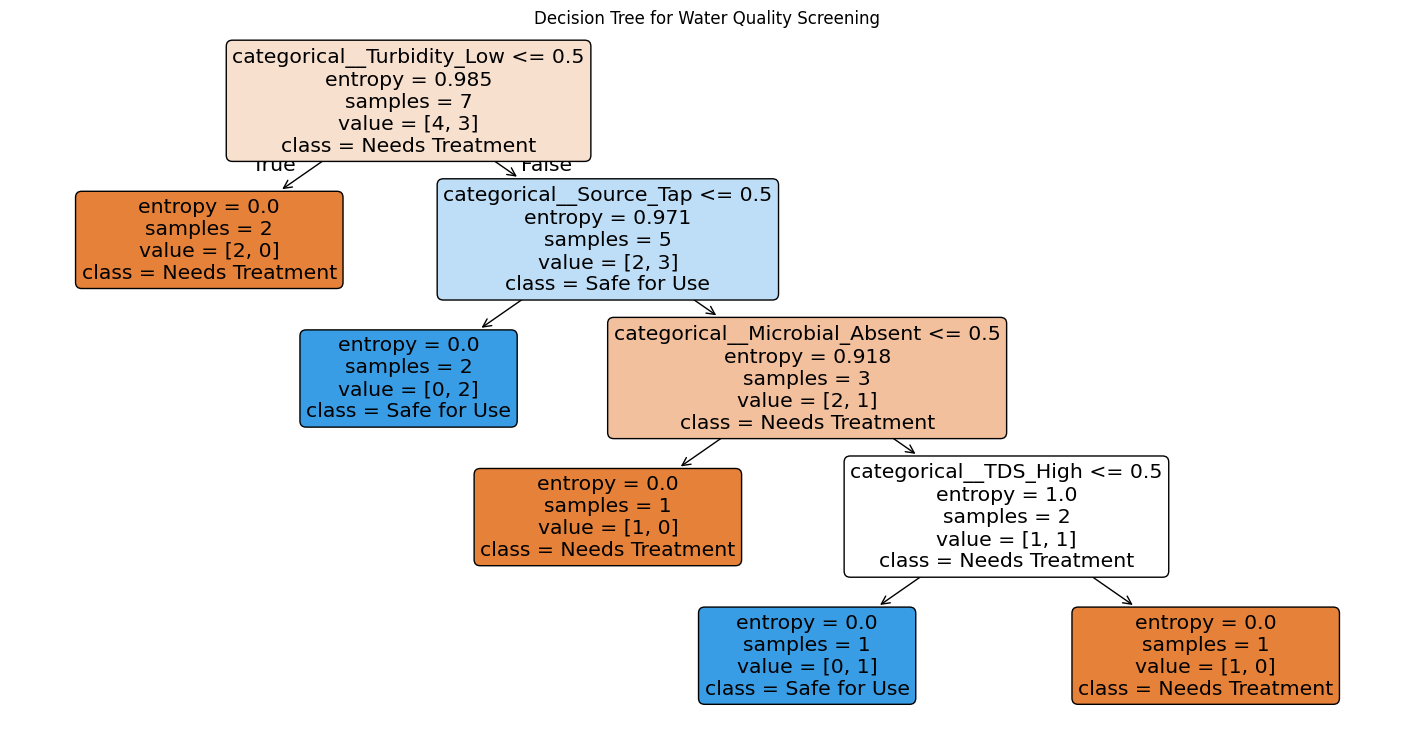


NEW WATER SAMPLE
        pH Turbidity     TDS  Chlorine Microbial Source
0  Neutral       Low  Normal  Adequate    Absent    Tap

PREDICTED RESULT:
Safe for Use

NOTE:
This is an educational screening model only.
It must NOT replace certified laboratory water-quality testing.


In [1]:
# WATER QUALITY SCREENING
# Candidate Elimination / Version Space + Decision Tree

import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --------------------------------------------------
# 1. CREATE SMALL EDUCATIONAL DATASET
# --------------------------------------------------

df = pd.DataFrame({
    "pH": ["Neutral","Neutral","Neutral","Neutral","Neutral",
           "Neutral","Neutral","Acidic","Neutral","Alkaline"],

    "Turbidity": ["Low","Low","Low","Low","Low",
                  "Low","High","Low","Low","High"],

    "TDS": ["Normal","Normal","Normal","Normal","Normal",
            "High","Normal","Normal","Normal","High"],

    "Chlorine": ["Adequate","Adequate","Adequate","Adequate","Adequate",
                 "Adequate","Adequate","Adequate","Low","Low"],

    "Microbial": ["Absent","Absent","Absent","Absent","Present",
                  "Absent","Absent","Absent","Absent","Present"],

    "Source": ["Borewell","Tap","Rainwater","Canal","Tap",
               "Tap","Tap","Tap","Tap","Canal"],

    "Target": ["Safe for Use","Safe for Use","Safe for Use","Safe for Use",
               "Needs Treatment","Needs Treatment","Needs Treatment",
               "Needs Treatment","Needs Treatment","Needs Treatment"]
})

attributes = ["pH","Turbidity","TDS","Chlorine","Microbial","Source"]

print("WATER QUALITY DATASET")
print("="*60)
print(df)

# --------------------------------------------------
# 2. BASIC DATA ANALYSIS
# --------------------------------------------------

print("\nFIRST FIVE RECORDS")
print(df.head())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

# Handle missing values
df.fillna(df.mode().iloc[0], inplace=True)

# --------------------------------------------------
# 3. CANDIDATE ELIMINATION / VERSION SPACE
# --------------------------------------------------

# Initial Specific Boundary
S = ["Ø"] * len(attributes)

# Initial General Boundary
G = ["?"] * len(attributes)

# Find-S style positive-example generalization
for _, row in df.iterrows():

    if row["Target"] == "Safe for Use":

        example = [row[a] for a in attributes]

        for i in range(len(attributes)):

            if S[i] == "Ø":
                S[i] = example[i]

            elif S[i] != example[i]:
                S[i] = "?"

print("\nINITIAL SPECIFIC BOUNDARY S")
print(["Ø"] * len(attributes))

print("\nINITIAL GENERAL BOUNDARY G")
print(G)

print("\nFINAL LEARNED HYPOTHESIS")
print("<" + ", ".join(S) + ">")

# --------------------------------------------------
# 4. ENTROPY AND INFORMATION GAIN
# --------------------------------------------------

def entropy(values):

    counts = pd.Series(values).value_counts()
    total = len(values)

    return -sum(
        (count/total) * math.log2(count/total)
        for count in counts
    )

def information_gain(data, attribute):

    total_entropy = entropy(data["Target"])
    weighted_entropy = 0

    for _, group in data.groupby(attribute):

        weight = len(group) / len(data)
        weighted_entropy += weight * entropy(group["Target"])

    return total_entropy - weighted_entropy

print("\nENTROPY OF DATASET")
print(round(entropy(df["Target"]), 3))

print("\nINFORMATION GAIN")
for attribute in attributes:
    print(attribute, ":", round(
        information_gain(df, attribute), 3
    ))

# --------------------------------------------------
# 5. DECISION TREE
# --------------------------------------------------

X = df[attributes]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer([
    ("categorical",
     OneHotEncoder(handle_unknown="ignore"),
     attributes)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        max_depth=4
    ))
])

model.fit(X_train, y_train)

# --------------------------------------------------
# 6. PREDICTION AND EVALUATION
# --------------------------------------------------

y_pred = model.predict(X_test)

print("\nTEST PREDICTIONS")
print(y_pred)

print("\nACTUAL VALUES")
print(y_test.values)

print("\nMODEL PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(
    precision_score(
        y_test, y_pred,
        pos_label="Safe for Use",
        zero_division=0
    ), 3))
print("Recall   :", round(
    recall_score(
        y_test, y_pred,
        pos_label="Safe for Use",
        zero_division=0
    ), 3))
print("F1 Score :", round(
    f1_score(
        y_test, y_pred,
        pos_label="Safe for Use",
        zero_division=0
    ), 3))

# --------------------------------------------------
# 7. DECISION TREE VISUALIZATION
# --------------------------------------------------

features = model.named_steps[
    "preprocessor"
].get_feature_names_out()

plt.figure(figsize=(18, 9))

plot_tree(
    model.named_steps["tree"],
    feature_names=features,
    class_names=model.named_steps["tree"].classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Water Quality Screening")
plt.show()

# --------------------------------------------------
# 8. TEST A NEW WATER SAMPLE
# --------------------------------------------------

new_sample = pd.DataFrame([{
    "pH": "Neutral",
    "Turbidity": "Low",
    "TDS": "Normal",
    "Chlorine": "Adequate",
    "Microbial": "Absent",
    "Source": "Tap"
}])

prediction = model.predict(new_sample)

print("\nNEW WATER SAMPLE")
print(new_sample)

print("\nPREDICTED RESULT:")
print(prediction[0])

print("\nNOTE:")
print("This is an educational screening model only.")
print("It must NOT replace certified laboratory water-quality testing.")